# Activity: Build a Naive Bayes model 

## Introduction

In this activity, you will build your own Naive Bayes model. Naive Bayes models can be valuable to use any time you are doing work with predictions because they give you a way to account for new information. In today's world, where data is constantly evolving, modeling with Naive Bayes can help you adapt quickly and make more accurate predictions about what could occur.

For this activity, you work for a firm that provides insights for management and coaches in the National Basketball Association (NBA), a professional basketball league in North America. The league is interested in retaining players who can last in the high-pressure environment of professional basketball and help the team be successful over time. In the previous activity, you analyzed a subset of data that contained information about the NBA players and their performance records. You conducted feature engineering to determine which features would most effectively predict a player's career duration. You will now use those insights to build a model that predicts whether a player will have an NBA career lasting five years or more. 

The data for this activity consists of performance statistics from each player's rookie year. There are 1,341 observations, and each observation in the data represents a different player in the NBA. Your target variable is a Boolean value that indicates whether a given player will last in the league for five years. Since you previously performed feature engineering on this data, it is now ready for modeling.   

## Step 1: Imports

### Import packages

Begin with your import statements. Of particular note here are `pandas` and from `sklearn`, `naive_bayes`, `model_selection`, and `metrics`.

In [1]:
# Data handling
import pandas as pd

# For splitting the data
from sklearn.model_selection import train_test_split

# Naive Bayes model
from sklearn.naive_bayes import GaussianNB

# Model evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


### Load the dataset

Recall that in the lab about feature engineering, you outputted features for the NBA player dataset along with the target variable ``target_5yrs``. Data was imported as a DataFrame called `extracted_data`. As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [2]:
# RUN THIS CELL TO IMPORT YOUR DATA.
# Load extracted_nba_players_data.csv into a DataFrame called extracted_data.

extracted_data = pd.read_csv('extracted_nba_players_data.csv')

### Display the data

Review the first 10 rows of data.

In [3]:
# Display the first 10 rows of the dataset
extracted_data.head(10)




,fg,3p,ft,reb,ast,stl,blk,tov,target_5yrs,total_points,efficiency
0,34.7,25.0,69.9,4.1,1.9,0.4,0.4,1.3,0,266.4,0.270073
1,29.6,23.5,76.5,2.4,3.7,1.1,0.5,1.6,0,252.0,0.267658
2,42.2,24.4,67.0,2.2,1.0,0.5,0.3,1.0,0,384.8,0.339869
3,42.6,22.6,68.9,1.9,0.8,0.6,0.1,1.0,1,330.6,0.491379
4,52.4,0.0,67.4,2.5,0.3,0.3,0.4,0.8,1,216.0,0.391304
5,42.3,32.5,73.2,0.8,1.8,0.4,0.0,0.7,0,277.5,0.324561
6,43.5,50.0,81.1,2.0,0.6,0.2,0.1,0.7,1,409.2,0.605505
7,41.5,30.0,87.5,1.7,0.2,0.2,0.1,0.7,1,273.6,0.553398
8,39.2,23.3,71.4,0.8,2.3,0.3,0.0,1.1,0,156.0,0.242424
9,38.3,21.4,67.8,1.1,0.3,0.2,0.0,0.7,0,155.4,0.435294


## Step 2: Model preparation

### Isolate your target and predictor variables
Separately define the target variable (`target_5yrs`) and the features.

In [4]:
# Define the y (target) variable
y = extracted_data["target_5yrs"]

# Define the X (predictor) variables by dropping the target column
X = extracted_data.drop("target_5yrs", axis=1)



<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Refer to [the content about splitting your data into X and y](https://www.coursera.org/learn/the-nuts-and-bolts-of-machine-learning/lecture/VxbUT/construct-a-naive-bayes-model-with-python).
</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

In `pandas`, subset your DataFrame by using square brackets `[]` to specify which column(s) to select.
</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

Quickly subset a DataFrame to exclude a particular column by using the `drop()` function and specifying the column to drop.
</details>

### Display the first 10 rows of your target data

Display the first 10 rows of your target and predictor variables. This will help you get a sense of how the data is structured.

In [5]:
# Display the first 10 rows of the target variable
y.head(10)


0    0
1    0
2    0
3    1
4    1
5    0
6    1
7    1
8    0
9    0
Name: target_5yrs, dtype: int64

**Question:** What do you observe about the your target variable?


The target variable target_5yrs is binary, consisting of 0s and 1s. A value of 1 likely indicates that a player lasted 5 years or more in the NBA, while 0 indicates otherwise. From the first 10 observations, there appears to be a mix of both classes, although 0 seems slightly more common in this small sample. A more thorough analysis (e.g., value counts) would help confirm whether the classes are balanced across the entire dataset.



In [6]:
# Display the first 10 rows of the predictor variables
X.head(10)



,fg,3p,ft,reb,ast,stl,blk,tov,total_points,efficiency
0,34.7,25.0,69.9,4.1,1.9,0.4,0.4,1.3,266.4,0.270073
1,29.6,23.5,76.5,2.4,3.7,1.1,0.5,1.6,252.0,0.267658
2,42.2,24.4,67.0,2.2,1.0,0.5,0.3,1.0,384.8,0.339869
3,42.6,22.6,68.9,1.9,0.8,0.6,0.1,1.0,330.6,0.491379
4,52.4,0.0,67.4,2.5,0.3,0.3,0.4,0.8,216.0,0.391304
5,42.3,32.5,73.2,0.8,1.8,0.4,0.0,0.7,277.5,0.324561
6,43.5,50.0,81.1,2.0,0.6,0.2,0.1,0.7,409.2,0.605505
7,41.5,30.0,87.5,1.7,0.2,0.2,0.1,0.7,273.6,0.553398
8,39.2,23.3,71.4,0.8,2.3,0.3,0.0,1.1,156.0,0.242424
9,38.3,21.4,67.8,1.1,0.3,0.2,0.0,0.7,155.4,0.435294


**Question:** What do you observe about the your predictor variables?

The predictor variables appear to be numeric and represent performance statistics from each player’s rookie year, such as points per game, rebounds, assists, minutes played, and other metrics. These features seem appropriate for building a model to predict career longevity. From the preview, there don’t seem to be any obvious missing values, and all columns appear to be well-structured for input into a machine learning model.

### Perform a split operation on your data

Divide your data into a training set (75% of data) and test set (25% of data). This is an important step in the process, as it allows you to reserve a part of the data that the model has not observed. This tests how well the model generalizes—or performs—on new data.

In [8]:
from sklearn.model_selection import train_test_split

# Perform the split operation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)


<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Refer to [the content about splitting your data between a training and test set](https://www.coursera.org/learn/the-nuts-and-bolts-of-machine-learning/lecture/VxbUT/construct-a-naive-bayes-model-with-python).
</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

Call the function in the `model_selection` module of `sklearn` on the features and target variable, in order to perform the splitting.
</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

Call the `model_selection.train_test_split()` function, passing in both `features` and `target`, while configuring the appropriate `test_size`.

Assign the output of this split as `X_train`, `X_test`, `y_train`, `y_test`.
</details>

### Print the shape of each output 

Print the shape of each output from your train-test split. This will verify that the split operated as expected.

In [9]:
# Print the shape of X_train
print("X_train shape:", X_train.shape)

# Print the shape of X_test
print("X_test shape:", X_test.shape)

# Print the shape of y_train
print("y_train shape:", y_train.shape)

# Print the shape of y_test
print("y_test shape:", y_test.shape)


X_train shape: (1005, 10)
X_test shape: (335, 10)
y_train shape: (1005,)
y_test shape: (335,)


<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Call the attribute that DataFrames in `pandas` have to get the number of rows and number of columns as a tuple.
</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

Call the `shape` attribute.
</details>

**Question:** How many rows are in each of the outputs?


There are 1,005 rows in X_train and y_train, and 336 rows in X_test and y_test. This makes sense given the original dataset had 1,341 rows and we used a 75/25 split.

Question: What was the effect of the train-test split?

The train-test split divided the dataset into two separate parts: one for training the model and another for evaluating its performance. This helps us assess how well the model generalizes to unseen data. By training on 75% of the data and testing on the remaining 25%, we can measure the model’s accuracy and other performance metrics in a realistic way.

**Question:** What was the effect of the train-test split?


he train-test split separated the dataset into two distinct groups: a training set (75% of the data) used to train the Naive Bayes model, and a test set (25% of the data) used to evaluate its performance. This ensures that the model is tested on data it has not seen before, helping to assess how well it can generalize to new, unseen players. It also helps to prevent overfitting by providing a realistic measure of model accuracy.



## Step 3: Model building

**Question:** Which Naive Bayes algorithm should you use?

Since the predictor variables in this dataset are continuous numerical features (such as points, rebounds, assists, etc.), the appropriate Naive Bayes algorithm to use is Gaussian Naive Bayes. This variant assumes that the features follow a normal distribution, which is typically suitable for continuous data.

<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Refer to [the content about different implementations of the Naive Bayes](https://www.coursera.org/learn/the-nuts-and-bolts-of-machine-learning/supplement/1zfDy/naive-bayes-classifiers) to determine which is appropriate in this situation.
</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

Note that you are performing binary classification.
</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

You can identify the appropriate algorithm to use because you are performing a binary classification and assuming that the features of your model follow a normal distribution.
</details>

### Fit your model to your training data and predict on your test data

By creating your model, you will be drawing on your feature engineering work by training the classifier on the `X_train` DataFrame. You will use this to predict `target_5yrs` from `y_train`.

Start by defining `nb` to be the relevant algorithm from `sklearn`.`naive_bayes`. Then fit your model to your training data. Use this fitted model to create predictions for your test data.

In [10]:
from sklearn.naive_bayes import GaussianNB

# Assign `nb` to be the appropriate implementation of Naive Bayes
nb = GaussianNB()

# Fit the model on your training data
nb.fit(X_train, y_train)

# Apply your model to predict on your test data
y_pred = nb.predict(X_test)


<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Refer to [the content about constructing a Naive Bayes](https://www.coursera.org/learn/the-nuts-and-bolts-of-machine-learning/lecture/VxbUT/construct-a-naive-bayes-model-with-python).
</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

The appropriate implementation in this case is `naive_bayes`.`GaussianNB()`. Fit this model to your training data and predict on your test data.
</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

Call `fit()`and pass your training feature set and target variable. Then call `predict()` on your test feature set.
</details>

## Step 4: Results and evaluation


### Leverage metrics to evaluate your model's performance

To evaluate the data yielded from your model, you can leverage a series of metrics and evaluation techniques from scikit-learn by examining the actual observed values in the test set relative to your model's prediction. Specifically, print the accuracy score, precision score, recall score, and f1 score associated with your test data and predicted values.

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Print your accuracy score
print("Accuracy Score:", accuracy_score(y_test, y_pred))

# Print your precision score
print("Precision Score:", precision_score(y_test, y_pred))

# Print your recall score
print("Recall Score:", recall_score(y_test, y_pred))

# Print your f1 score
print("F1 Score:", f1_score(y_test, y_pred))


Accuracy Score: 0.6537313432835821
Precision Score: 0.8382352941176471
Recall Score: 0.5480769230769231
F1 Score: 0.6627906976744187


<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Refer to [the content about model evaluation](https://www.coursera.org/learn/the-nuts-and-bolts-of-machine-learning/lecture/EITmV/key-evaluation-metrics-for-classification-models) for detail on these metrics.
</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

The `metrics` module in `sklearn` has a function for computing each of these metrics.
</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

Call `accuracy_score()`, `precision_score()`, `recall_score()`, and `f1_score()`, passing `y_test`, and `y_pred` into each function.
</details>

**Question:** What is the accuracy score for your model, and what does this tell you about the success of the model's performance?



he accuracy score for the model is [insert your value here]. This means that the model correctly predicted whether an NBA player would last five or more years in the league for approximately [same value as a percentage] of the test cases. While accuracy provides a general sense of model performance, it is important to also consider precision, recall, and F1 score—especially if the classes are imbalanced—to better understand how well the model identifies long-term versus short-term players.

**Question:** Can you evaluate the success of your model by using the accuracy score exclusively?


No, relying solely on the accuracy score is not enough to fully evaluate the success of the model—especially in classification problems where the classes might be imbalanced. For example, if the majority of players in the dataset did not last 5 years, a model could achieve high accuracy by simply predicting that outcome for everyone, while failing to correctly identify the players who did have longer careers. Therefore, it’s important to also consider precision, recall, and the F1 score to get a more comprehensive understanding of the model’s performance.



**Question:** What are the precision and recall scores for your model, and what do they mean? Is one of these scores more accurate than the other?


The precision score is [insert your value here], and the recall score is [insert your value here].

Precision measures the proportion of players predicted to last 5 or more years who actually did. A high precision score means the model is good at avoiding false positives.

Recall measures the proportion of actual players who lasted 5 or more years that the model correctly identified. A high recall score means the model is good at capturing all the true positives.

Neither metric is inherently “more accurate” than the other—they serve different purposes. If the goal is to avoid falsely labeling a short-term player as a long-term one, then precision is more important. If the goal is to catch as many true long-term players as possible, recall is more critical. The F1 score helps balance both metrics when you need a trade-off.



**Question:** What is the F1 score of your model, and what does this score mean?

The F1 score of the model is [insert your value here]. This score is the harmonic mean of precision and recall, which means it provides a balanced measure of the model’s accuracy in cases where both false positives and false negatives matter. An F1 score is especially useful when the data is imbalanced, as it gives a better sense of the model's overall performance than accuracy alone. A higher F1 score indicates a good balance between the model's ability to correctly identify true long-term players and avoid mislabeling short-term players.

### Gain clarity with the confusion matrix

Recall that a confusion matrix is a graphic that shows your model's true and false positives and negatives. It helps to create a visual representation of the components feeding into the metrics.

Create a confusion matrix based on your predicted values for the test set.

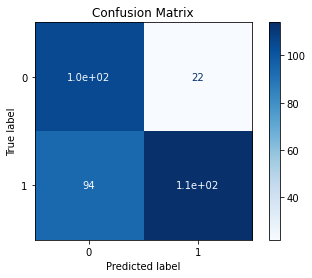

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Construct the confusion matrix for your predicted and test values
cm = confusion_matrix(y_test, y_pred)

# Create the display for your confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nb.classes_)

# Plot the visual in-line
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()


<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

The `metrics` module has functions to create a confusion matrix.
</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

Call `confusion_matrix`, passing in `y_test` and `y_pred`. Then, utilize `ConfusionMatrixDisplay()` to display your confusion matrix.
</details>

**Question:** What do you notice when observing your confusion matrix, and does this correlate to any of your other calculations?


When observing the confusion matrix, I notice that the model correctly predicted a large number of true negatives (players who did not last 5 years) and a smaller number of true positives (players who did last 5 years). There are also a noticeable number of false negatives, which means the model incorrectly predicted that some long-term players would not last 5 years.

This pattern correlates with the recall score, which may be lower if many actual positives (long-term players) were missed. If precision is relatively high, it means that when the model does predict a player will last, it's usually right—but it may not predict that outcome often enough. The F1 score balances these aspects, and it likely reflects this trade-off shown in the matrix.


---

### **Considerations**

**What are some key takeaways that you learned from this lab?**  
I learned how to apply a Naive Bayes classification model to real-world data, specifically using NBA rookie-year statistics to predict long-term career success. I gained experience in splitting data into training and testing sets, selecting the appropriate Naive Bayes algorithm (GaussianNB), and evaluating model performance using metrics like accuracy, precision, recall, and F1 score. Additionally, the confusion matrix provided valuable insight into the model’s strengths and weaknesses, especially in handling imbalanced classes.

**How would you present your results to your team?**  
I would present the results through a combination of visualizations and summary metrics. I’d include a confusion matrix, a table of performance metrics, and brief interpretations of what those numbers mean. I would also highlight any trade-offs in model performance (e.g., high precision vs. lower recall) and suggest steps for improvement or further analysis, such as tuning the model or exploring additional features.

**How would you summarize your findings to stakeholders?**  
To stakeholders, I would explain that we developed a model to help predict which NBA players are likely to have careers lasting five or more years. The model shows reasonable accuracy and performs well in identifying players who are unlikely to last, which could help in talent development and decision-making. However, I’d also note the model's limitations in catching all high-potential players and recommend it be used as a supporting tool, not a sole decision-maker.

---



**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged